In [ ]:
from deq.p1_strategy import all_metrics_analysis
from deq.plot import p1_delta_bar
from deq.deq import ext, deq_col_specs

ext = {
    **ext,
    **deq_col_specs(
        suffix='_a',
        pick_equity_mid=0.0255
    ),
    **deq_col_specs(
        suffix='_b',
        pick_equity_mid=0.0265
    ),
    **deq_col_specs(
        suffix='_c',
        pick_equity_mid=0.0285
    ),
}  


metrics = ["deq", "deq_a", "deq_b", "deq_c"]

result = all_metrics_analysis(metrics=metrics, results_filter={'lhs': 'format_day', 'op': '>', 'rhs': 2})
p1_delta_bar(result, metrics=metrics)

In [ ]:
from deq.plot import p1_line_plot
from deq.p1_strategy import skill_cohort_table

p1_line_plot(result, metrics=metrics)
p1_line_plot(result, mode="entropy", metrics=metrics)
p1_line_plot(result, mode="entropy_loss", metrics=metrics)

In [ ]:
early_format = {"lhs": "format_day", "op": "<", "rhs": 13}
res_d1 = all_metrics_analysis(
    metrics=metrics,
    results_filter=early_format,
    metric_filter={"lhs": "format_day", "op": "<", "rhs": 3},
    deq_days=2,
)

tag_d1 = "Early format using day 2 metrics"
p1_line_plot(res_d1, mode="wr_delta", metrics=metrics, title_extra=tag_d1)
p1_line_plot(res_d1, mode="entropy_loss", metrics=metrics, title_extra=tag_d1)

In [ ]:
early_top = {"$and": [{"player_cohort": "Top"}, early_format]}
late_format = {"$not": early_format}
tag_mid = "Late format using early top player metrics"
res_mid = all_metrics_analysis(
    metric_filter=early_top, results_filter=late_format, deq_days=12
)
p1_line_plot(res_mid, mode="wr_delta", metrics=metrics, title_extra=tag_mid)

p1_line_plot(res_mid, mode="entropy_loss", metrics=metrics, title_extra=tag_mid)

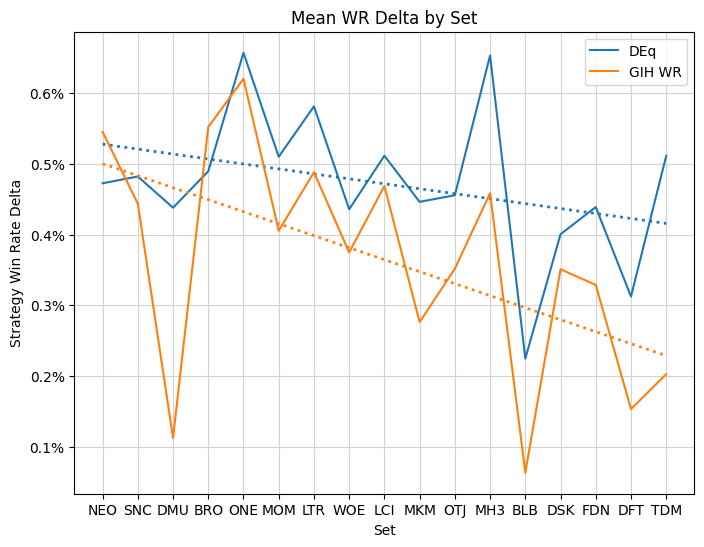

In [10]:
from deq.p1_strategy import set_by_set_results
from deq.plot import set_by_set_plot

set_by_set = set_by_set_results()
set_by_set_plot(set_by_set)